# Using Neurokit2 to process data

In [78]:
#%pip install neurokit2
import neurokit2 as nk
import pandas as pd

Processing data from the EmotiBit file

In [79]:
eda_file = r"data\Relaxed(EYES CLOSED)_normal sitting (1)\JULY10 (1)\Day1_July10 _emotibit (1)\2025-07-10_14-37-42-966335_EA (1).csv"
raw_data = pd.read_csv(eda_file)

## Data Selection and Prewview

Select a range

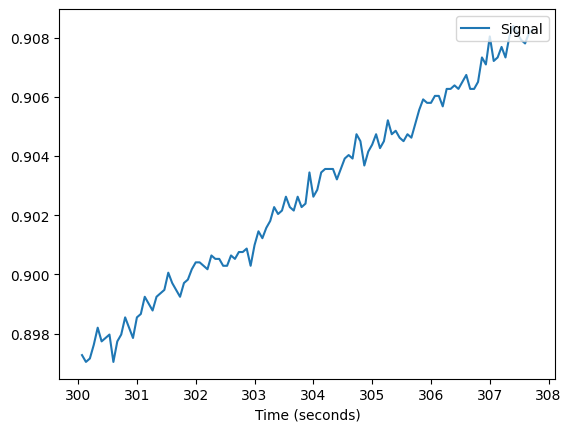

In [80]:
df_min = raw_data["LocalTimestamp"].min() + 300
df_max = raw_data["LocalTimestamp"].max() - 440
df = raw_data[(raw_data["LocalTimestamp"]>df_min) & (raw_data["LocalTimestamp"]<df_max)]
df_ea = df["EA"]

nk.signal_plot(df_ea, sampling_rate=15) # Check basic graph

Filters

In [81]:
from scipy.signal import butter, filtfilt

sample_rate_eda = 15

def low_pass_filter(data, cutoff_freq, sample_rate):
    nyquist = 0.5 * sample_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(1, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def bandpass_filter(data, lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

Applying a bandpass filter 0.1 - 5 Hz

In [82]:
df_ea_filtered = bandpass_filter(df_ea, lowcut=0.1, highcut=5, fs=sample_rate_eda)

Obtain basic EDA plot

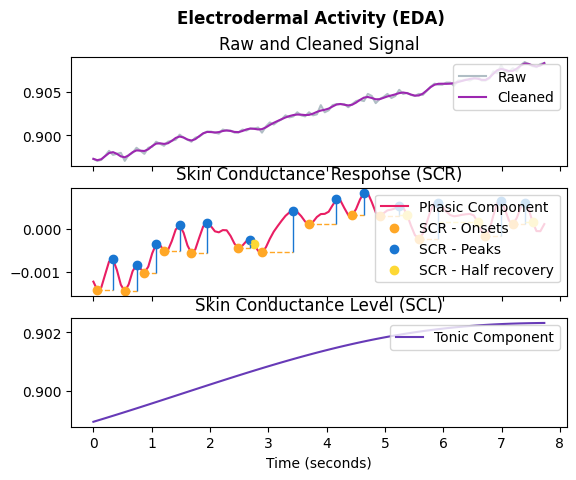

In [ ]:
# raw eda signal
signals, info = nk.eda_process(df_ea, sampling_rate=15)

plt = nk.eda_plot(signals, info)

Filtered EDA

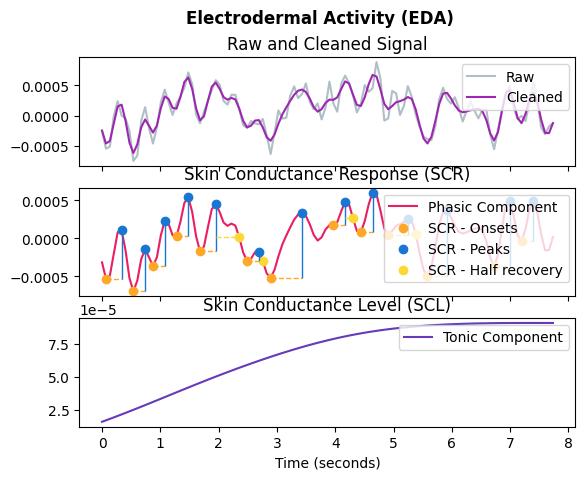

In [84]:
f_signals, f_info = nk.eda_process(df_ea_filtered, sampling_rate=15)
nk.eda_plot(f_signals, f_info)

## Analyze EDA data

The processing function does two important things for our purpose: Firstly, it cleans the signal. Secondly, it detects the location of 1) peak onsets, 2) peak amplitude, and 3) half-recovery time. Let’s extract these from the output.

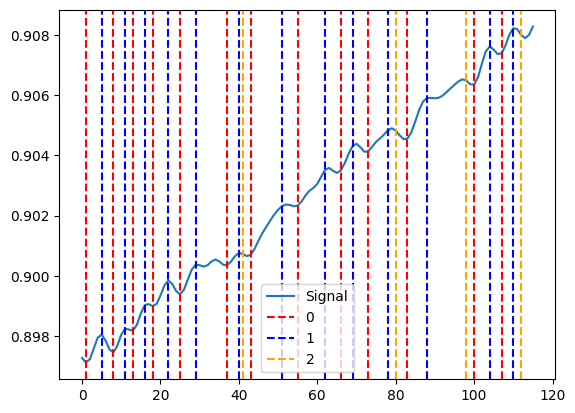

In [85]:
# Extract clean EDA and SCR features
cleaned = signals["EDA_Clean"]
features = [info["SCR_Onsets"], info["SCR_Peaks"], info["SCR_Recovery"]]

# Visualize SCR features in cleaned EDA signal
plot = nk.events_plot(features, cleaned, color=['red', 'blue', 'orange'])

In [95]:
epochs = nk.epochs_create(signals, events=1 ,sampling_rate=15)
nk.eda_eventrelated(epochs)

,Label,Event_Onset,EDA_Peak_Amplitude,EDA_SCR,SCR_Peak_Amplitude,SCR_Peak_Amplitude_Time,SCR_RiseTime,SCR_RecoveryTime
1,1,58,0.00086,1,0.000585,0.269006,0.466667,NaN


In [96]:
nk.eda_intervalrelated(signals, sampling_rate=15)

,SCR_Peaks_N,SCR_Peaks_Amplitude_Mean,EDA_Tonic_SD,EDA_Sympathetic,EDA_SympatheticN,EDA_Autocorrelation
0,13.0,0.000617,0.001064,NaN,NaN,NaN
